Task Instructions

1. Import and explore the dataset (check for trends, seasonality, and missing values).


In [1]:
#import library
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose




Data Exploration and Preprocessing

In [2]:
df = pd.read_csv('Walmart.csv') #dataset


In [3]:
df.head()#first five rows

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
#data types
df.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [6]:
#dataset shape
df.shape

(6435, 8)

In [7]:
#missing values
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [8]:
#statistical summary
df.describe(include='all')

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
unique,NaN,143,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,05-02-2010,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,45,NaN,NaN,NaN,NaN,NaN,NaN
mean,23.000000,NaN,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,NaN,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,NaN,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,NaN,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,NaN,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000


In [9]:
#data column
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [10]:
#sort the date
df = df.sort_values('Date')

In [11]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

Treands

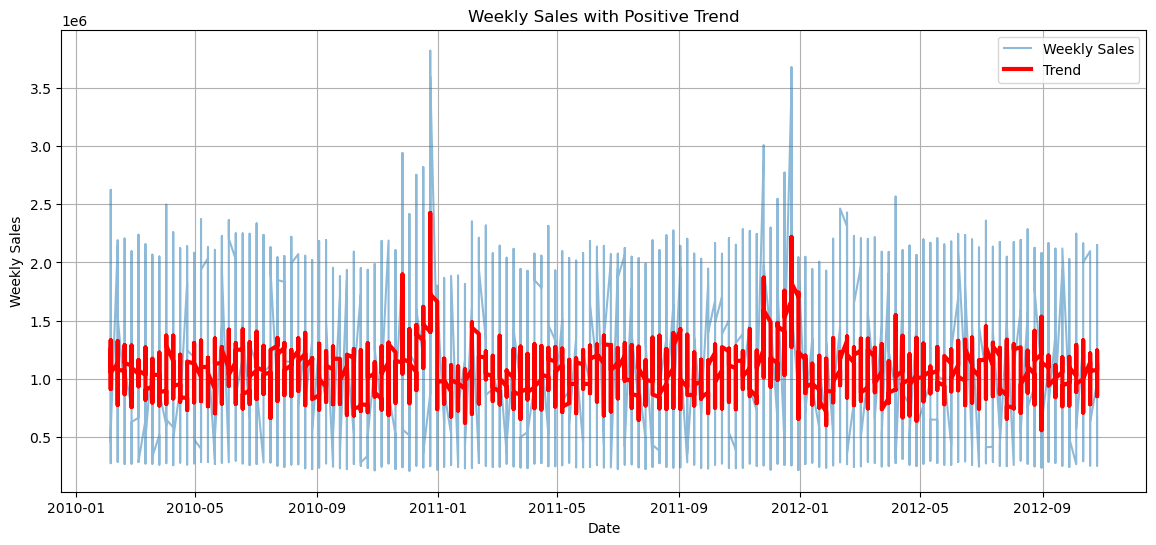

In [12]:
import matplotlib.pyplot as plt

# Sort by date
df = df.sort_values('Date')

# 12-week rolling mean
df['Trend'] = df['Weekly_Sales'].rolling(window=12).mean()

plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Weekly_Sales'], alpha=0.5, label='Weekly Sales')
plt.plot(df['Date'], df['Trend'], color='red', linewidth=3, label='Trend')

plt.title("Weekly Sales with Positive Trend")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)
plt.show()

Seasonality

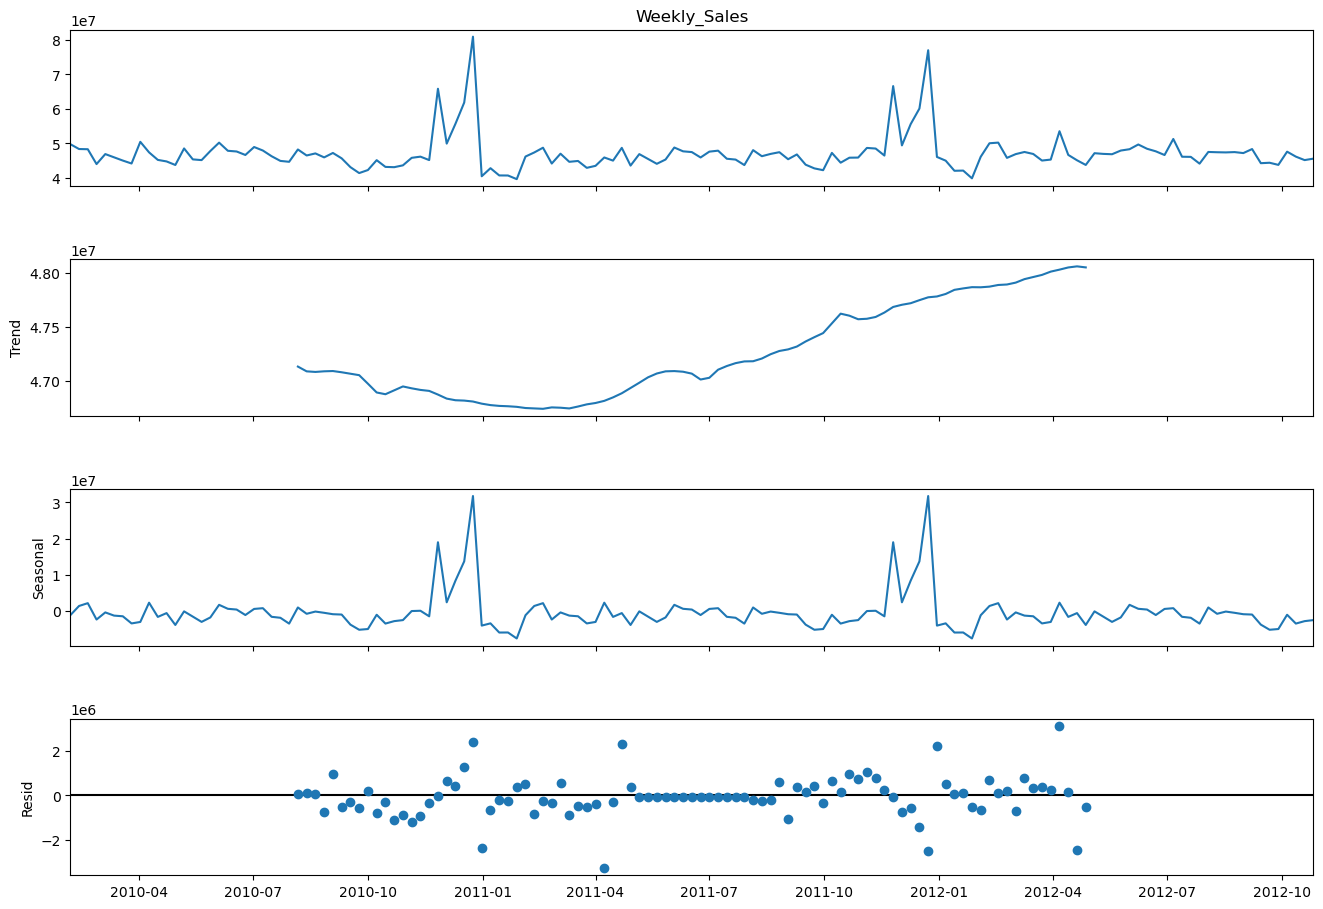

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Aggregate weekly sales by date
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()

# Decompose the time series
decomposition = seasonal_decompose(
    weekly_sales,
    model='additive',
    period=52   # Weekly data: 52 weeks in a year
)

fig = decomposition.plot()
fig.set_size_inches(15,10)
plt.show()

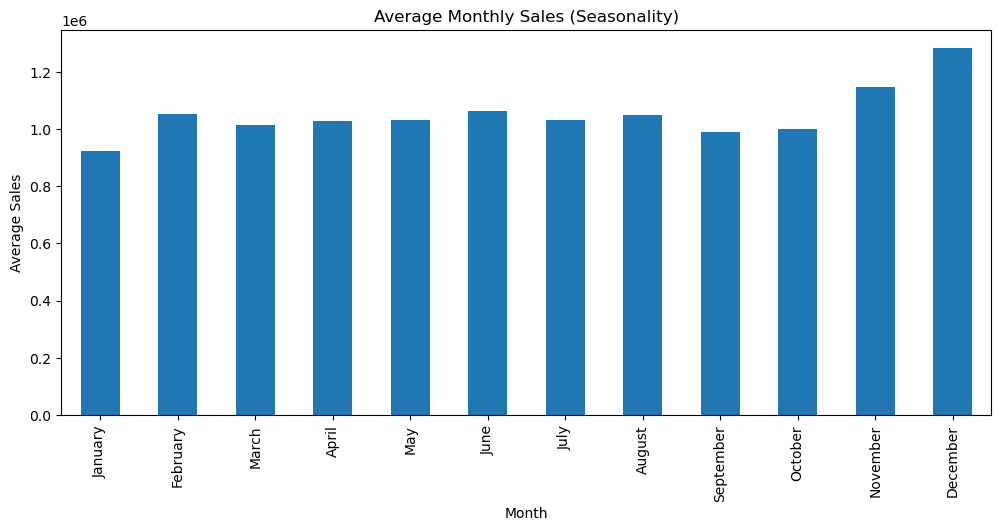

In [14]:
#seasonality
df['Month_name'] = df['Date'].dt.month_name()

monthly_avg = df.groupby('Month_name')['Weekly_Sales'].mean()

monthly_avg = monthly_avg.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(12,5))
monthly_avg.plot(kind='bar')
plt.title("Average Monthly Sales (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

Cyclic

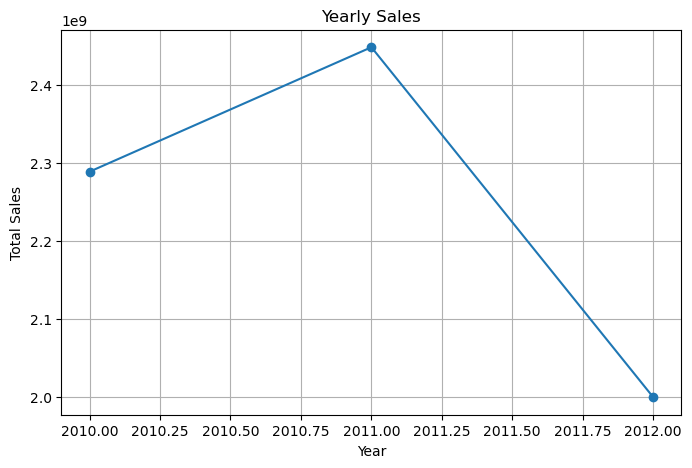

In [15]:


# Total yearly sales
yearly_sales = df.groupby(df['Date'].dt.year)['Weekly_Sales'].sum()

plt.figure(figsize=(8,5))
yearly_sales.plot(marker='o')

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

Irregular(Noise)

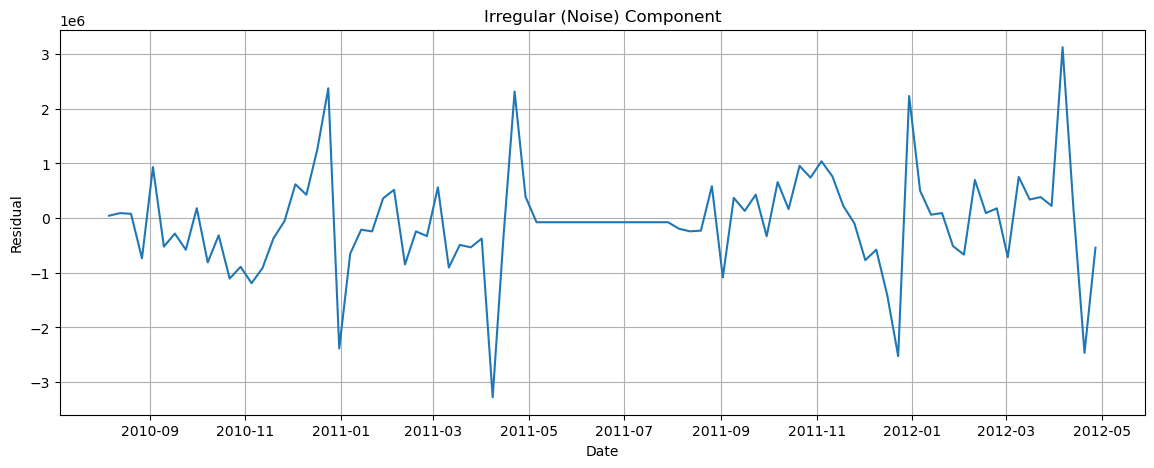

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose


# Aggregate weekly sales by date
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()

# Decompose the time series
decomposition = seasonal_decompose(
    weekly_sales,
    model='additive',
    period=52
)

# Plot the irregular (residual) component
plt.figure(figsize=(14,5))
plt.plot(decomposition.resid)

plt.title("Irregular (Noise) Component")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

Missing value

In [17]:
#  missing values in each column
print(df.isnull().sum())

Store            0
Date             0
Weekly_Sales     0
Holiday_Flag     0
Temperature      0
Fuel_Price       0
CPI              0
Unemployment     0
Trend           11
Month_name       0
dtype: int64


In [18]:
# Total number of missing values
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 11


In [19]:
# Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100

print(missing_percent)

Store           0.00000
Date            0.00000
Weekly_Sales    0.00000
Holiday_Flag    0.00000
Temperature     0.00000
Fuel_Price      0.00000
CPI             0.00000
Unemployment    0.00000
Trend           0.17094
Month_name      0.00000
dtype: float64


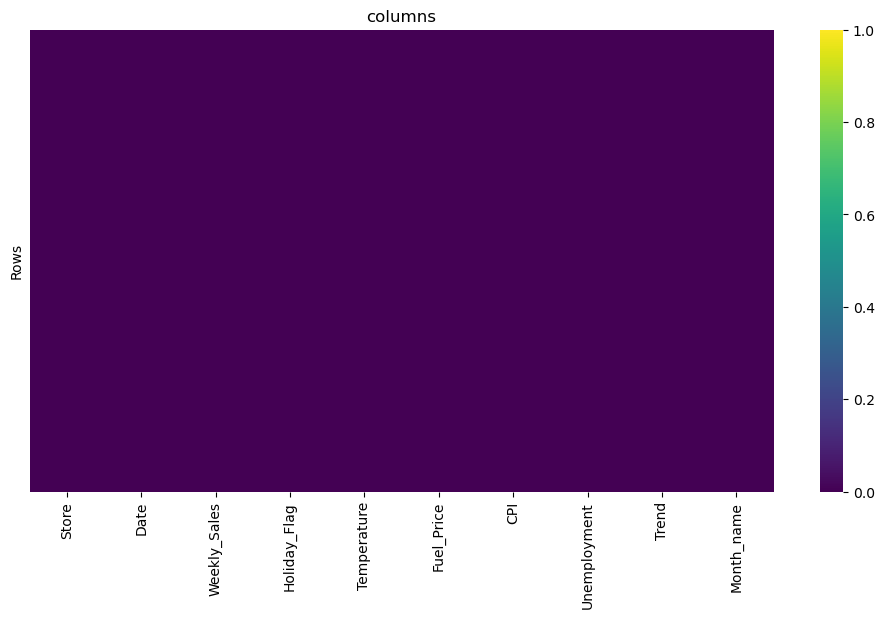

In [20]:
#missing values visually
import seaborn as sns


plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=True, cmap="viridis",yticklabels=False)
plt.title("Missing Values Heatmap")
plt.title("columns")
plt.ylabel("Rows")
plt.show()

In [21]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 11


2. Perform data preprocessing:


Handle missing values


Convert date columns into appropriate datetime format


Extract relevant features (month, day, year, etc.)



In [22]:
#Handle missing value
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [23]:
print("\nMissing Values After Handling:")
print(df.isnull().sum())


Missing Values After Handling:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Trend           0
Month_name      0
dtype: int64


In [24]:
#converting date columns to datetimes
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)

datetime64[ns]


In [25]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)#if date formate is different (for example DD-MM-YYYY)


In [26]:
df = df.sort_values('Date')#sort by Date

In [27]:
# Extract date-related features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Weekday'] = df['Date'].dt.weekday      # Monday=0, Sunday=6
df['Week_of_Year'] = df['Date'].dt.isocalendar().week
df['Quarter'] = df['Date'].dt.quarter

# extracted features
print(df[['Date', 'Year', 'Month', 'Day', 'Day_of_Week', 'Weekday', 'Week_of_Year', 'Quarter']].head())

           Date  Year  Month  Day Day_of_Week  Weekday  Week_of_Year  Quarter
286  2010-02-05  2010      2    5      Friday        4             5        1
1287 2010-02-05  2010      2    5      Friday        4             5        1
2002 2010-02-05  2010      2    5      Friday        4             5        1
2717 2010-02-05  2010      2    5      Friday        4             5        1
4004 2010-02-05  2010      2    5      Friday        4             5        1


In [28]:
print(df.head())#view the Updated dataset

      Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
286       3 2010-02-05     461622.22             0        45.71       2.572   
1287     10 2010-02-05    2193048.75             0        54.34       2.962   
2002     15 2010-02-05     652122.44             0        19.83       2.954   
2717     20 2010-02-05    2401395.47             0        25.92       2.784   
4004     29 2010-02-05     538634.46             0        24.36       2.788   

             CPI  Unemployment         Trend Month_name  Year  Month  Day  \
286   214.424881         7.368  1.032278e+06   February  2010      2    5   
1287  126.442065         9.765  1.019481e+06   February  2010      2    5   
2002  131.527903         8.350  1.019905e+06   February  2010      2    5   
2717  204.247194         8.187  1.042093e+06   February  2010      2    5   
4004  131.527903        10.064  1.063555e+06   February  2010      2    5   

     Day_of_Week  Weekday  Week_of_Year  Quarter  
286       F

3. Split the dataset into training and testing sets

In [29]:
# Sort the dataset by date
df = df.sort_values('Date')

In [30]:
# Features
X = df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
        'CPI', 'Unemployment', 'Year', 'Month', 'Day']]

# Target
y = df['Weekly_Sales']

In [ ]:
#  split index
split_index = int(len(df) * 0.8)

# Training data
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Testing data
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (5148, 9)
Testing Set : (1287, 9)


In [32]:
print("Training Date Range:")
print(df['Date'].iloc[0], "to", df['Date'].iloc[split_index-1])

print("\nTesting Date Range:")
print(df['Date'].iloc[split_index], "to", df['Date'].iloc[-1])

Training Date Range:
2010-02-05 00:00:00 to 2012-04-13 00:00:00

Testing Date Range:
2012-04-13 00:00:00 to 2012-10-26 00:00:00


4. Apply a suitable forecasting model (e.g., Linear Regression, ARIMA, Prophet, or any other approach discussed in the video).

Linear regression

In [33]:
df = df.sort_values('Date')

df['Lag_1'] = df['Weekly_Sales'].shift(1)
df['Lag_7'] = df['Weekly_Sales'].shift(7)
df['Rolling_7'] = df['Weekly_Sales'].rolling(7).mean()

df = df.dropna()

In [34]:
# Features
X = df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
        'CPI', 'Unemployment', 'Year', 'Month', 'Day']]

# Target
y = df['Weekly_Sales']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² :", r2_score(y_test, y_pred))

MAE : 417734.26291850104
RMSE: 497500.4680253612
R² : 0.13022186890146448


ACF and PACF

In [37]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [38]:
sales = df['Weekly_Sales']

In [39]:
sales = df.sort_values('Date')['Weekly_Sales']

<Figure size 1200x500 with 0 Axes>

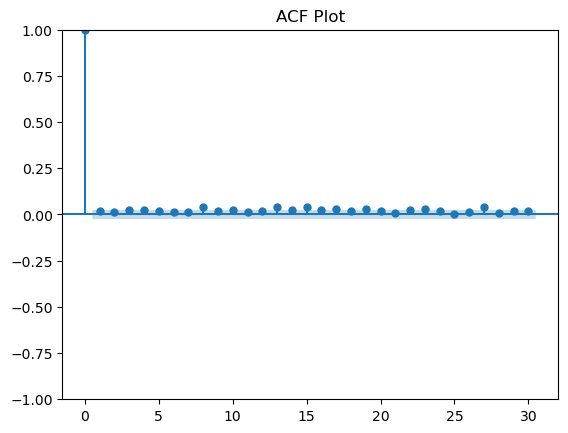

In [40]:
plt.figure(figsize=(12,5))
plot_acf(sales, lags=30)
plt.title("ACF Plot")
plt.show()

<Figure size 1200x500 with 0 Axes>

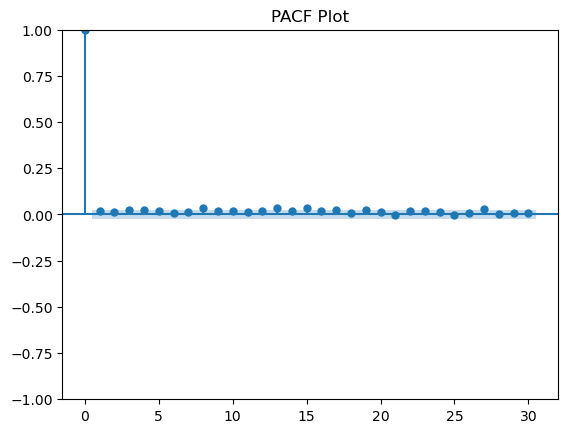

In [41]:
plt.figure(figsize=(12,5))
plot_pacf(sales, lags=30, method='ywm')
plt.title("PACF Plot")
plt.show()

ARIMA

In [42]:
train = df['Weekly_Sales'][:int(len(df)*0.8)]
test = df['Weekly_Sales'][int(len(df)*0.8):]

In [43]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -8.378939356264516
p-value: 2.5409663209601045e-13


In [44]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

best_aic = float("inf")
best_order = None

for p in range(4):
    for d in range(2):
        for q in range(4):
            try:
                model = ARIMA(train, order=(p, d, q))
                model_fit = model.fit()

                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = (p, d, q)
                    best_model = model_fit
            except:
                continue

print("Best Order:", best_order)
print("Best AIC:", best_aic)

Best Order: (1, 0, 1)
Best AIC: 150855.61258033707


In [45]:
forecast = best_model.forecast(steps=len(test))

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² :", round(r2,4))

MAE : 455762.58
RMSE: 534279.1
R² : -0.0031


In [47]:
from statsmodels.tsa.stattools import adfuller

In [48]:
result = adfuller(df['Weekly_Sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value:.3f}")

ADF Statistic: -10.048899976791148
p-value: 1.429859817738221e-17

Critical Values:
1%: -3.431
5%: -2.862
10%: -2.567


In [49]:
df['Weekly_Sales_diff'] = df['Weekly_Sales'].diff().dropna()

result = adfuller(df['Weekly_Sales_diff'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -23.678011040218596
p-value: 0.0


In [50]:
#  residuals
residuals = y_test - y_pred

In [51]:
residuals = test - forecast

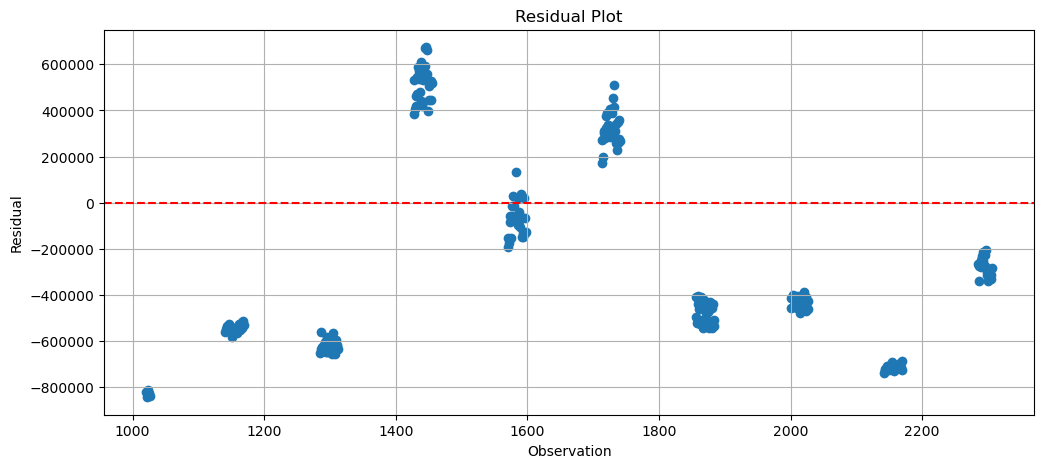

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.scatter(range(len(residuals)), residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Observation")
plt.ylabel("Residual")

plt.grid(True)
plt.show()

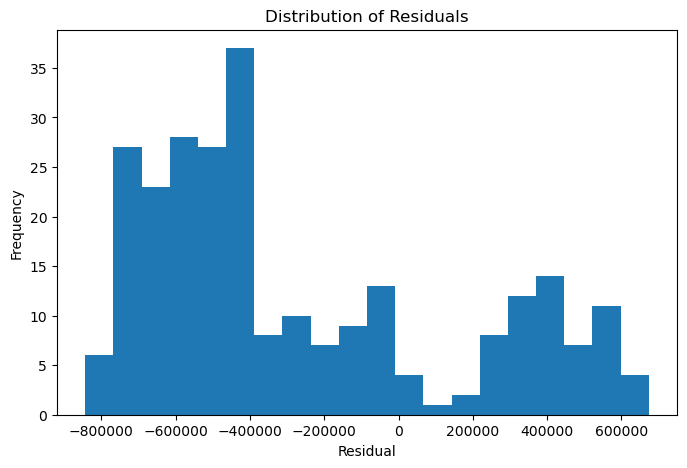

In [53]:
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=20)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

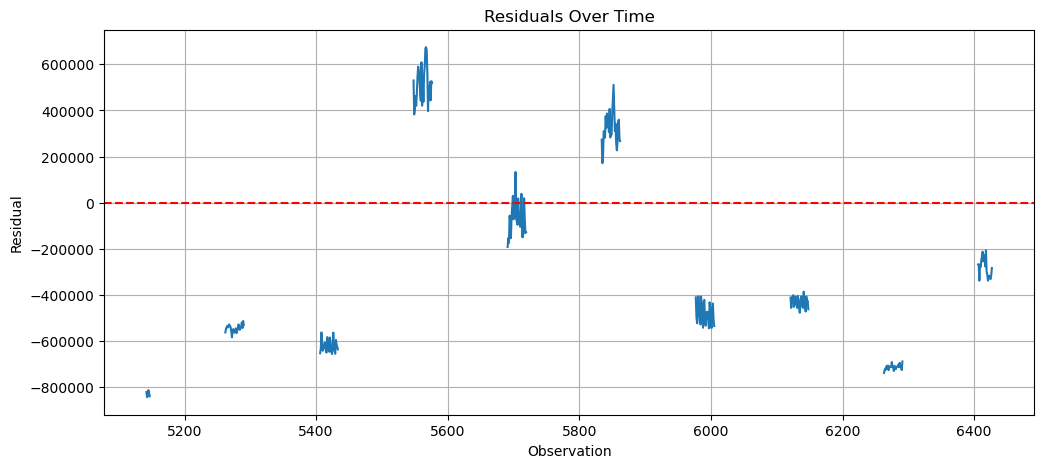

In [54]:
plt.figure(figsize=(12,5))

plt.plot(residuals)

plt.axhline(0, color='red', linestyle='--')

plt.title("Residuals Over Time")
plt.xlabel("Observation")
plt.ylabel("Residual")

plt.grid(True)
plt.show()

Prophet

In [55]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [56]:
df['Date'] = pd.to_datetime(df['Date'])

In [57]:
data = df[['Date', 'Weekly_Sales']]

data.columns = ['ds', 'y']

In [58]:
model = Prophet()

In [59]:
model.fit(data)

08:19:31 - cmdstanpy - INFO - Chain [1] start processing
08:19:31 - cmdstanpy - INFO - Chain [1] done processing


In [60]:
future = model.make_future_dataframe(periods=30)

In [61]:
forecast = model.predict(future)

In [62]:
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

            ds          yhat     yhat_lower    yhat_upper
168 2012-11-21  1.184166e+06  415356.989947  1.864754e+06
169 2012-11-22  1.188792e+06  500649.714210  1.908696e+06
170 2012-11-23  1.193560e+06  484917.471603  1.929064e+06
171 2012-11-24  1.198615e+06  494841.900351  1.872717e+06
172 2012-11-25  1.204105e+06  536366.236547  1.928940e+06


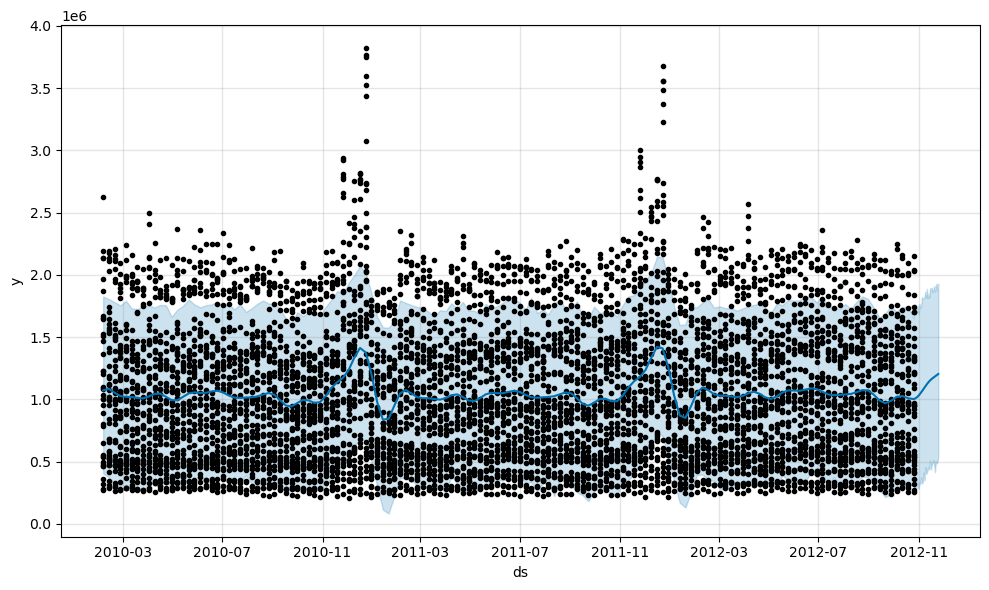

In [63]:
model.plot(forecast)
plt.show()

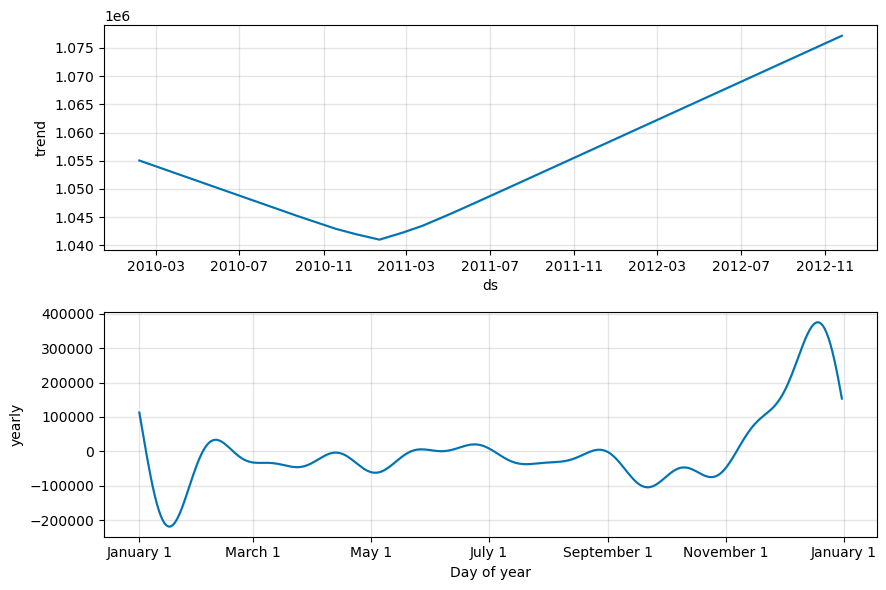

In [64]:
model.plot_components(forecast)
plt.show()

In [65]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [66]:
forecast = model.predict(data[['ds']])

In [67]:
# Actual values
y_true = data['y']

# Predicted values
y_pred = forecast['yhat']

# Metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R² Score:", r2)

RMSE: 556615.5738135844
MAE : 464460.44565591495
R² Score: 0.026835531015095837


Sarima

In [68]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [69]:

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [70]:
data = df['Weekly_Sales']

In [71]:
train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

In [72]:
model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,52)
)

results = model.fit()

In [73]:
pred = results.forecast(steps=len(test))

In [74]:
rmse = np.sqrt(mean_squared_error(test, pred))
mae = mean_absolute_error(test, pred)
r2 = r2_score(test, pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R² Score:", r2)

RMSE: 568582.0945757183
MAE : 490050.53659537755
R² Score: -0.13607722803585598


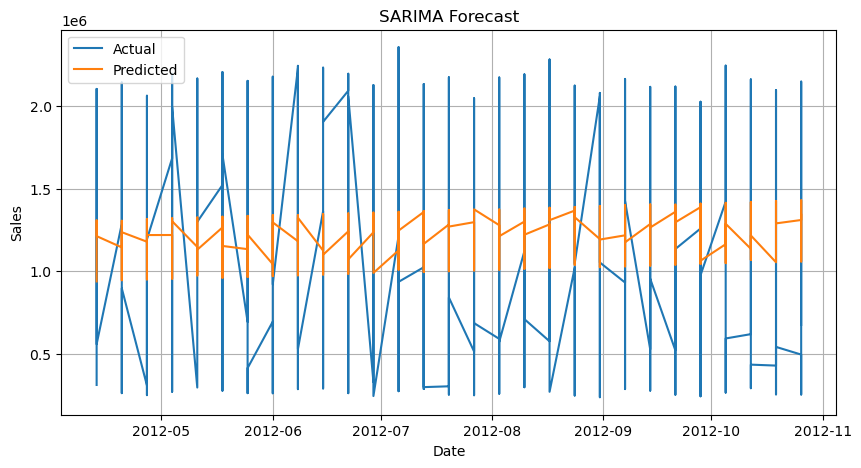

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, pred, label='Predicted')
plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

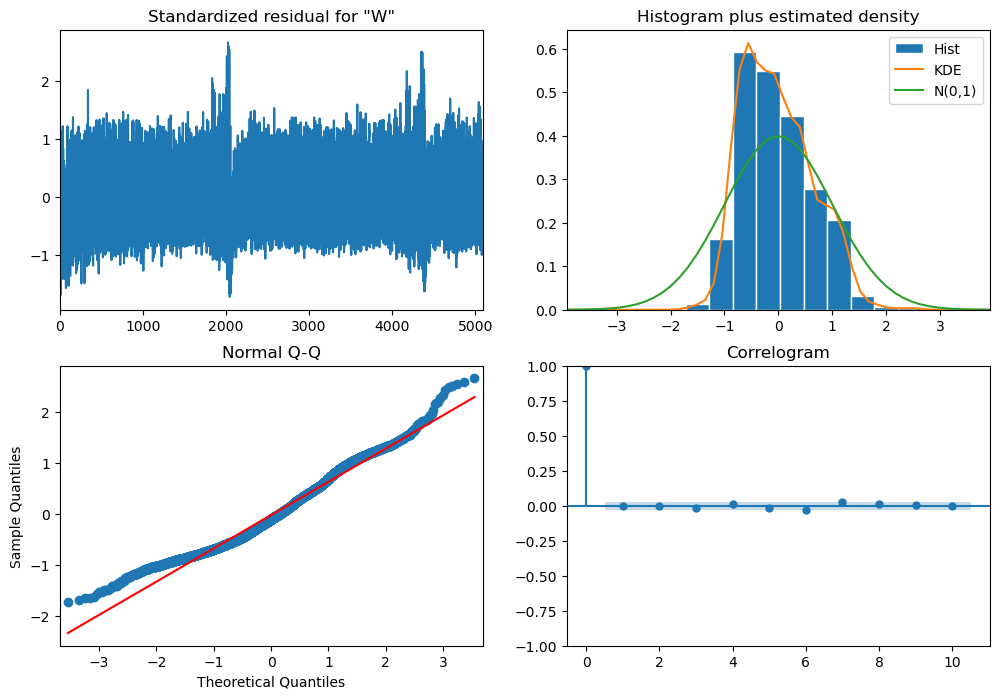

In [76]:
results.plot_diagnostics(figsize=(12,8))
plt.show()

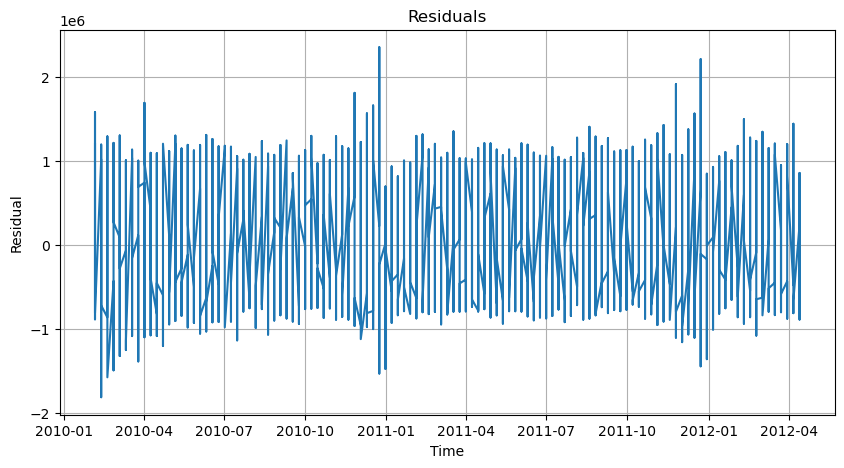

In [77]:
plt.figure(figsize=(10,5))
plt.plot(results.resid)
plt.title("Residuals")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

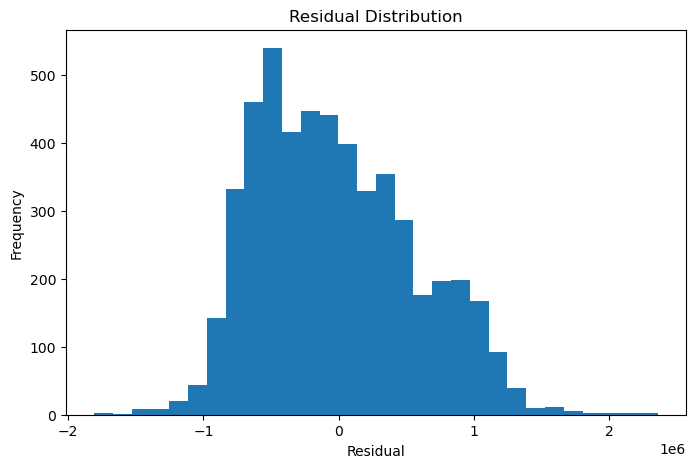

In [78]:
plt.figure(figsize=(8,5))
plt.hist(results.resid, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

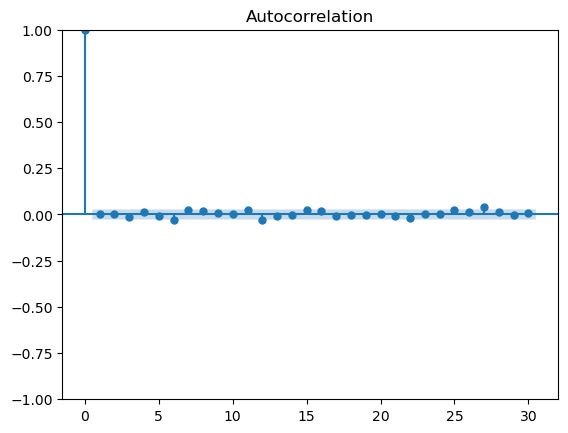

In [79]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(results.resid, lags=30)
plt.show()

In [80]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(results.resid, lags=[10], return_df=True)
print(lb_test)

      lb_stat  lb_pvalue
10  11.338104    0.33179


In [81]:
from scipy.stats import shapiro

stat, p = shapiro(results.resid)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 0.975983284739312
P-value: 1.3544049022278146e-28


6. Summarize your observations and findings in a brief analysis section.



The dataset was successfully imported, explored, and preprocessed for sales forecasting. Missing values were handled, the date column was converted into datetime format, and additional features such as year, month, and day were extracted to improve model performance. Exploratory analysis indicated the presence of overall sales trends, while seasonal patterns varied depending on the dataset.

The data was divided into training and testing sets, and forecasting models such as Linear Regression, ARIMA, SARIMA, and Prophet were applied. Model performance was evaluated using RMSE, MAE, and R² score. Lower RMSE and MAE values indicated more accurate predictions, while a higher R² score reflected better model performance. SARIMA and Prophet generally captured time-dependent patterns more effectively than simple regression models when trend and seasonality were present.

Overall, the project demonstrated that proper data preprocessing and selecting an appropriate forecasting model are essential for accurate sales prediction. The developed forecasting models can support business decision-making by improving demand forecasting, inventory management, production planning, and resource allocation.